In [8]:
import argparse
import h5py
import matplotlib.pyplot as plt
import numpy as np
from collections import namedtuple

ParserArgs = namedtuple('ParserArgs', ['inj_file', 'bank_file', 'output_file', 'x_param', 'y_param', 'snr_threshold'])

bank_file = "../bank/mini-bank.hdf"
inj_file = "../results/foundmissed/H1L1V1-MULTIINSPIRAL_HM_fakedata_512_512s_snr_10_FOUNDMISSED-1267735954-512.h5"
output_file = "./figures/H1L1V1-MULTIINSPIRAL_HM_fakedata_512_512s_snr_10_FOUNDMISSED-1267735954-512.png"

args = ParserArgs(
    inj_file=inj_file, bank_file=bank_file, output_file=output_file, x_param='mass1', y_param='mass2', snr_threshold=7.0)


<Figure size 720x432 with 0 Axes>

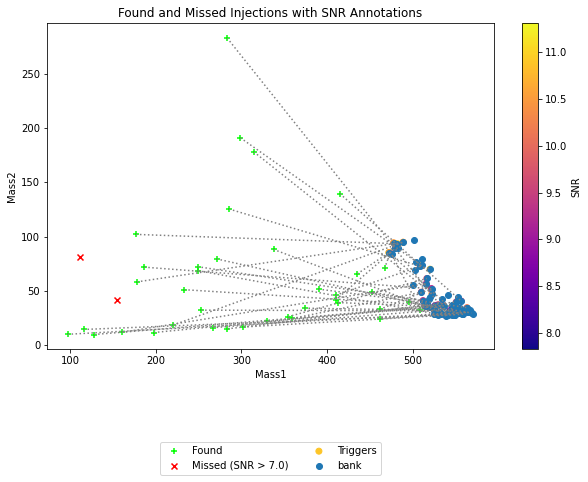

In [24]:
# Load the "found", "missed", and "triggers" datasets
with h5py.File(args.inj_file, "r") as file:
    found_dataset = file["found"]
    found_x = found_dataset[args.x_param][:]
    found_y = found_dataset[args.y_param][:]
    found_snr = found_dataset["network_optimal_snr"][:]
    triggers_dataset = file["triggers"]
    template_id = triggers_dataset["template_id"][:]
    triggers_snr = triggers_dataset["snr_2_filter"][:]
    missed_dataset = file["missed"]
    missed_x = missed_dataset[args.x_param][:]
    missed_y = missed_dataset[args.y_param][:]
    missed_snr = missed_dataset["network_optimal_snr"][:]

# Load the template params
with h5py.File(args.bank_file, "r") as file:
    # breakpoint()
    triggers_x = file[args.x_param][:][template_id]
    triggers_y = file[args.y_param][:][template_id]

# Create a scatter plot
plt.figure(figsize=(10,6))
fig, ax = plt.subplots(figsize=(10,6))
scatter_found = ax.scatter(found_x, found_y, marker="+", color="lime", label="Found")
# Add missed triggers as black or red crosses based on SNR threshold
missed_label = "Missed (SNR > {})".format(args.snr_threshold)
missed_mask = missed_snr < args.snr_threshold
if any(~missed_mask):
    _ = ax.scatter(
        missed_x[~missed_mask],
        missed_y[~missed_mask],
        marker="x",
        color="red",
        label=missed_label,
    )
if any(missed_mask):
    _ = ax.scatter(
        missed_x[missed_mask],
        missed_y[missed_mask],
        marker="x",
        color="black",
        label=missed_label.replace(">", "<"),
    )
scatter_triggers = ax.scatter(
    triggers_x, triggers_y, c=triggers_snr, cmap="plasma", label="Triggers"
)
plt.xlabel(args.x_param.capitalize())
plt.ylabel(args.y_param.capitalize())
plt.title("Found and Missed Injections with SNR Annotations")

# # Add annotations for SNR values
# for i, (trig_snr, opt_snr) in enumerate(zip(triggers_snr, found_snr)):
#     ax.annotate("{:.1f}".format(trig_snr), (triggers_x[i], triggers_y[i]))
#     ax.annotate("{:.1f}".format(opt_snr), (found_x[i], found_y[i]))
# for i, opt_snr in enumerate(missed_snr[~missed_mask]):
#     ax.annotate("{:.1f}".format(opt_snr), (missed_x[~missed_mask][i], missed_y[~missed_mask][i]))

# Add lines connecting corresponding points in the found and triggers datasets
ax.plot(
    [found_x, triggers_x],
    [found_y, triggers_y],
    color="gray",
    linestyle="dotted",
)
scatter_bank = plt.scatter(
    bank_x, bank_y, label="bank"
)

# Add a colorbar
cbar = plt.colorbar(scatter_triggers)
cbar.set_label("SNR")

# Add a legend
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.4), ncol=2)

# Save the figure to the output file
# plt.savefig(args.output_file, bbox_inches="tight")

plt.show()


In [17]:
len(found_x), len(missed_x)

(40, 2)

In [20]:
with h5py.File(args.bank_file, "r") as file:
    bank_x = file[args.x_param][:]
    bank_y = file[args.y_param][:]

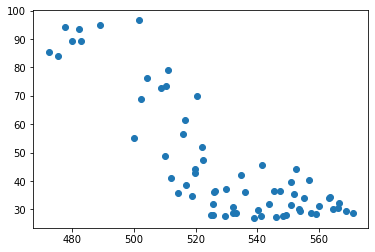

In [23]:
scatter_bank = plt.scatter(
    bank_x, bank_y, label="bank"
)